#### 12.5 凸包

- 函数`hull = cv2.convexHull(points[, clockwise[, returnPoints]])`用于获取轮廓的凸包，其中
    - 返回值 hull 为凸包的角点
    - points 是轮廓
    - clockwise 为`True`时，凸包角点按顺时针方向排列；反之以逆时针方向排列
    - returnPoints 默认值为`True`，函数返回凸包角点的坐标值；否则返回凸包角点的索引

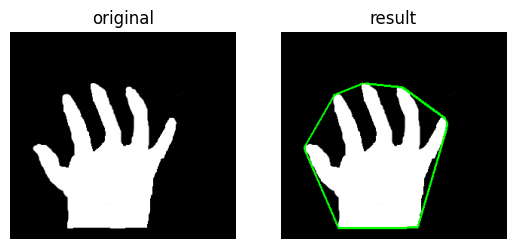

In [ ]:
import matplotlib.pyplot as plt
import cv2
# ------------ 读取并绘制原始图像 -----------------
o = cv2.imread('hand.bmp')  
plt.subplot(121)
plt.imshow(o)
plt.title("original")
plt.axis("off")
# ------------- 提取轮廓 ------------------
gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
# ------------ 得到凸包的角点 -----------------
hull = cv2.convexHull(contours[0])  # 默认返回凸包的角点坐标
# ------------- 绘制凸包 ----------------
cv2.polylines(o, [hull], True, (0, 255, 0), 2)

plt.subplot(122)
plt.imshow(o)
plt.title("result")
plt.axis("off")
plt.show()

- 凸缺陷是凸包与轮廓之间的部分。通常用四个特征值表示凸缺陷，分别是：
    - 起点：表示当前凸缺陷的起点位置
    - 终点：表示当前凸缺陷的终点位置
    - 轮廓上距离凸包最远的点
    - 最远点到凸包的近似距离
- 函数 `convexityDefects = cv2.convexityDefects(contour, convexhull)` 用来获取凸缺陷，其中
    - 返回值 convexityDefects 为凸缺陷点集数组，每一行包含[起点, 终点, 轮廓上距离凸包最远的点, 最远点到凸包的近似距离]，其中前三个值是轮廓点在轮廓点集中的索引
    - contour 是轮廓
    - convexhull 是凸包

defects.shape = (12, 1, 4)


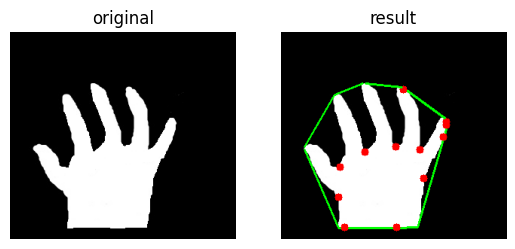

In [ ]:
import cv2
#----------------原图--------------------------
img = cv2.imread('hand.bmp')
plt.subplot(121)
plt.imshow(img)
plt.title("original")
plt.axis("off")
#----------------构造轮廓--------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, binary = cv2.threshold(gray, 127, 255, 0)
contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
#----------------凸包--------------------------
cnt = contours[0]
hull = cv2.convexHull(cnt, returnPoints = False)
defects = cv2.convexityDefects(cnt,hull)
# print("defects =\n",defects)
print("defects.shape =", defects.shape)
#----------------构造凸缺陷--------------------------
for i in range(defects.shape[0]):
    s, e, f, d = defects[i,0]
    start = tuple(cnt[s][0])
    end = tuple(cnt[e][0])
    far = tuple(cnt[f][0])
    cv2.line(img, start, end, [0,255,0], 2)
    cv2.circle(img, far, 5, [255,0,0], -1)
#----------------显示结果、释放图像--------------------------
plt.subplot(122)
plt.imshow(img)
plt.title("result")
plt.axis("off")
plt.show()

##### 几何学测试
- 函数`retval = cv2.isContourConvex(contour)`用来判断轮廓是否是凸形的，其中
    - 返回值 retval 为`True`时，表示轮廓为凸形的；反之不是凸形的
    - contour 是要判断的轮廓
- 函数`retval = cv2.pointPolygonTest(contour, pt, measureDist)`用来计算点到多边形轮廓的最短距离（垂线距离），其中
    - contour 是要判断的轮廓
    - pt 为待判定的点
    - measureDist 表示距离的判定方式。
        - 当值为`True`时，计算点到轮廓的距离。如果点在轮廓的外部，返回值是负数；如果点在轮廓上，返回值为0；如果点在轮廓内部，返回值为正数
        - 若该值为`False`，只返回"-1", "0"和"1"中的一个值，表示点与轮廓的相对位置关系，分别对应轮廓外部、轮廓上和轮廓内部

distA = 16.891650862259112
distB = -81.17585848021565
distC = -0.0


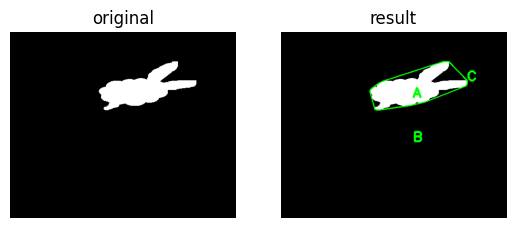

hull =  [[[381  69]]

 [[423 112]]

 [[423 120]]

 [[422 122]]

 [[419 125]]

 [[327 161]]

 [[293 169]]

 [[223 179]]

 [[216 179]]

 [[214 178]]

 [[213 177]]

 [[202 138]]

 [[202 135]]

 [[203 133]]

 [[206 130]]

 [[221 119]]

 [[224 117]]

 [[230 114]]

 [[369  69]]]


In [ ]:
import cv2
import matplotlib.pyplot as plt
#----------------原始图像-------------------------
o = cv2.imread('cs.bmp')
plt.subplot(121)
plt.imshow(o)
plt.title("original")
plt.axis("off")
#----------------获取凸包------------------------  
gray = cv2.cvtColor(o,cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
hull = cv2.convexHull(contours[0])
cv2.polylines(o, [hull], True, (0, 255, 0), 2)
#----------------内部点A的距离-------------------------
distA = cv2.pointPolygonTest(hull, (300, 150), True)  
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(o, 'A', (300,150), font, 1, (0,255,0), 3)
print("distA =", distA) 
#----------------外部点B的距离-------------------------
distB = cv2.pointPolygonTest(hull, (300, 250), True)  
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(o, 'B', (300,250), font, 1, (0,255,0), 3)
print("distB =", distB) 
#------------正好处于边缘上的点C的距离-----------------
distC = cv2.pointPolygonTest(hull, (423, 112), True)  
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(o, 'C', (423,112), font, 1, (0,255,0), 3)
print("distC =", distC) 
plt.subplot(122)
plt.imshow(o)
plt.title("result")
plt.axis("off")
plt.show()

print("hull = ", hull)   # 打印轮廓点集获取轮廓上的点

#### 12.6 Hausdorff 距离
- Hausdorff 距离是指“一个集合到另一个集合中最近点的最大距离”。更一般来说，计算图像A与图像B间Hausdorff距离的计算方法是：
    - 对图像A中的每一个点，寻找其距离图像B的最短距离，将这组最短距离中的最大值作为从A到B的Hausdorff直接距离`H(A, B)`
    - 对图像B中的每一个点，寻找其距离图像A的最短距离，将这组最短距离中的最大值作为从A到B的Hausdorff直接距离`H(B, A)`
    - 将上述两个距离中的较大值作为Hausdorff距离`H(A, B)`
- 函数`retval = cv2. createHausdorffDistanceExtractor([, distanceFlag[, rankProp]])`，其中
    - distanceFlag 为距离标记
    - rankProp 是范围在 0 到 1 之间的比例值

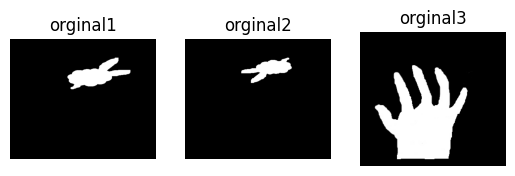

自身Hausdorff距离 d1 = 0.0
旋转缩放后Hausdorff距离 d2 = 18.357559204101562
不相似对象Hausdorff距离 d3 = 57.27128601074219


In [ ]:
import cv2
import matplotlib.pyplot as plt
#-----------读取原始图像--------------------
o1 = cv2.imread('cs.bmp')
o2 = cv2.imread('cs3.bmp') 
o3 = cv2.imread('hand.bmp') 
plt.subplot(131)
plt.imshow(o1)
plt.title("orginal1")
plt.axis("off")
plt.subplot(132)
plt.imshow(o2)
plt.title("orginal2")
plt.axis("off")
plt.subplot(133)
plt.imshow(o3)
plt.title("orginal3")
plt.axis("off")
plt.show()
# ----------- 色彩转换 --------------------
gray1 = cv2.cvtColor(o1,cv2.COLOR_BGR2GRAY) 
gray2 = cv2.cvtColor(o2,cv2.COLOR_BGR2GRAY) 
gray3 = cv2.cvtColor(o3,cv2.COLOR_BGR2GRAY) 
#----------- 阈值处理 --------------------
ret, binary1 = cv2.threshold(gray1,127,255,cv2.THRESH_BINARY) 
ret, binary2 = cv2.threshold(gray2,127,255,cv2.THRESH_BINARY) 
ret, binary3 = cv2.threshold(gray3,127,255,cv2.THRESH_BINARY) 
#----------- 提取轮廓 --------------------
contours1, hierarchy = cv2.findContours(binary1, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
contours2, hierarchy = cv2.findContours(binary2, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
contours3, hierarchy = cv2.findContours(binary3, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
cnt1 = contours1[0]
cnt2 = contours2[0]
cnt3 = contours3[0]
#-----------构造距离提取算子--------------------
hd = cv2.createHausdorffDistanceExtractor()
# -----------计算距离--------------------
d1 = hd.computeDistance(cnt1, cnt1)
print("自身的Hausdorff距离 d1 =", d1)
d2 = hd.computeDistance(cnt1, cnt2)
print("旋转缩放后的Hausdorff距离 d2 =", d2)
d3 = hd.computeDistance(cnt1, cnt3)
print("不相似对象的Hausdorff距离 d3 =", d3)
#-----------显示距离--------------------
cv2.waitKey()
cv2.destroyAllWindows()

#### 12.7 轮廓的特征值
$$ 宽高比 = \dfrac{宽度(\text{Width})}{高度(\text{Height})} $$
$$ \text{Extend} = \dfrac{轮廓面积(对象面积)}{矩形边界面积} $$
$$ \text{Solidity} = \dfrac{轮廓面积(对象面积)}{凸包面积} $$
$$ 等效直径(\text{Equivalent Diameter}) = \sqrt{\dfrac{4 \times 轮廓面积}{\pi}} $$

宽高比 = 2.1506849315068495
Extend = 0.6717127650292296
Equivalent Diameter = 99.00522529212108


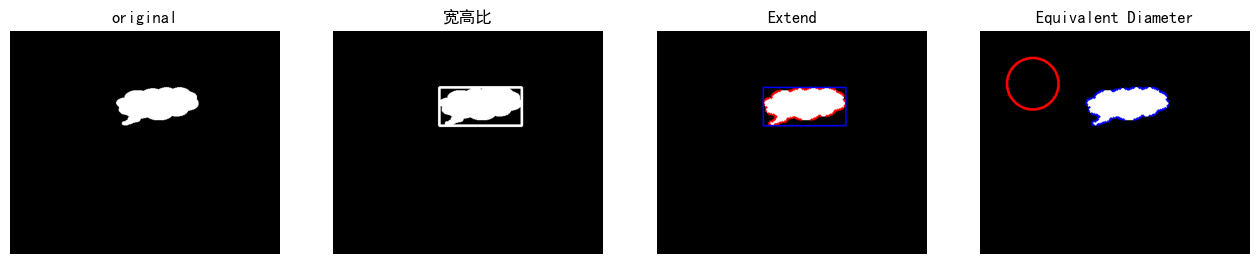

Solidity = 0.6752344564084751


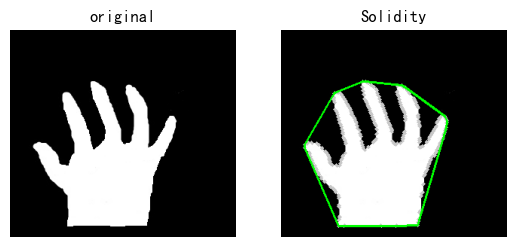

In [37]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# matplotlib 默认字体 DejaVu Sans 不支持中文，直接显示会报警告。
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

o = cv2.imread('cc.bmp')  
plt.figure(figsize=(16,6))
plt.subplot(141)
plt.imshow(o)
plt.title("original")
plt.axis("off")

gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
x, y, w, h = cv2.boundingRect(contours[0])

# 计算宽高比
o1 = o.copy()
cv2.rectangle(o1, (x,y), (x+w,y+h), (255,255,255), 3)
aspectRatio = float(w)/h
print("宽高比 =", aspectRatio)
plt.subplot(142)
plt.imshow(o1)
plt.title("宽高比")
plt.axis("off")

# 计算 Extend
o2 = o.copy()
cv2.drawContours(o2, contours[0], -1, (255,0,0), 3) 
cv2.rectangle(o2, (x,y), (x+w,y+h), (0,0,255), 2)
rectArea = w * h
cntArea = cv2.contourArea(contours[0])
extend = float(cntArea)/rectArea
print("Extend =", extend)
plt.subplot(143)
plt.imshow(o2)
plt.title("Extend")
plt.axis("off")

# 计算等效直径
o3 = o.copy()
cv2.drawContours(o3, contours[0], -1, (0,0,255), 3) 
cntArea = cv2.contourArea(contours[0])
equiDiameter = np.sqrt(4*cntArea/np.pi)
print("Equivalent Diameter =", equiDiameter)
cv2.circle(o3, (100,100), int(equiDiameter/2), (255,0,0), 3) # 画出等直径大小的圆
plt.subplot(144)
plt.imshow(o3)
plt.title("Equivalent Diameter")
plt.axis("off")
plt.show()

# 计算 Solidity
o = cv2.imread('hand.bmp')  
plt.subplot(121)
plt.imshow(o)
plt.title("original")
plt.axis("off")

gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
cv2.drawContours(o, contours[0], -1, (200,200,200), 3) 
cntArea = cv2.contourArea(contours[0])
hull = cv2.convexHull(contours[0])
hullArea = cv2.contourArea(hull)
cv2.polylines(o, [hull], True, (0, 255, 0), 2)
solidity = float(cntArea) / hullArea
print("Solidity =", solidity)
plt.subplot(122)
plt.imshow(o)
plt.title("Solidity")
plt.axis("off")
plt.show()

##### 掩膜与像素点
- 函数`idx = cv2.findNonZero(src)`用于查找非零元素的索引，其中
    - 返回值 idx 表示非零元素的索引位置，每个元素对应的是(列号，行号)的格式
    - src 表示要查找非零元素的图像

pixelpoints1.shape = (1400, 1, 2)
pixelpoints2.shape = (7892, 1, 2)


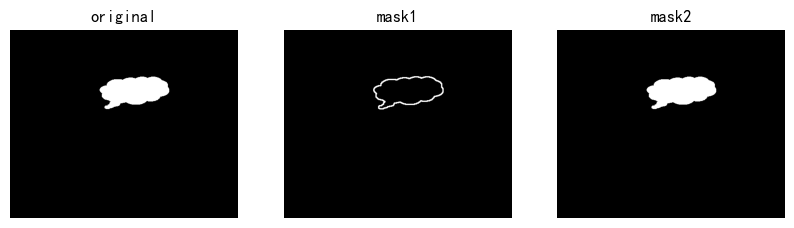

In [41]:
import cv2
import numpy as np
# -----------------读取原始图像----------------------
o = cv2.imread('cc.bmp')
plt.figure(figsize=(10, 4))  
plt.subplot(131)
plt.imshow(o)
plt.title("original")
plt.axis("off")
# ----------------获取轮廓------------------------
gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
cnt = contours[0]
#-----------------绘制空心轮廓------------------------
mask1 = np.zeros(gray.shape, np.uint8)
cv2.drawContours(mask1, [cnt], 0, 255, 2)
pixelpoints1 = cv2.findNonZero(mask1)
print("pixelpoints1.shape =", pixelpoints1.shape)
# print("pixelpoints1=\n",pixelpoints1)
mask1 = cv2.cvtColor(mask1, cv2.COLOR_BGR2RGB)  
plt.subplot(132)
plt.imshow(mask1)
plt.title("mask1")
plt.axis("off")
#-----------------绘制实心轮廓---------------------
mask2 = np.zeros(gray.shape, np.uint8)
cv2.drawContours(mask2, [cnt], 0, 255, -1)
pixelpoints2 = cv2.findNonZero(mask2)
print("pixelpoints2.shape =", pixelpoints2.shape)
# print("pixelpoints2=\n",pixelpoints2)
mask2 = cv2.cvtColor(mask2, cv2.COLOR_BGR2RGB) 
plt.subplot(133)
plt.imshow(mask2)
plt.title("mask2")
plt.axis("off")
plt.show()

- 函数`min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(imgray, mask=mask)`用于在指定对象内查找最大值、最小值及其位置，其中
    - min_val, max_val 分别表示最小值和最大值
    - min_loc, max_loc 分别表示最小值的位置和最大值的位置
    - imgray 是单通道图像
    - mask 是掩膜，可以通过掩膜得到指定区域内的最值信息
- 函数`mean_val = cv2.mean(img, mask=mask)`用于计算一个对象的平均颜色或平均灰度，其中
    - 返回值 mean_val 表示返回的平均值
    - img 是原图像
    - mask 表示掩膜

minVal = 42.0
maxVal = 200.0
minLoc = (87, 90)
maxLoc = (90, 110)
meanVal = (85.45594913714804, 85.45594913714804, 85.45594913714804, 0.0)
meanVal_gray = (85.45594913714804, 0.0, 0.0, 0.0)


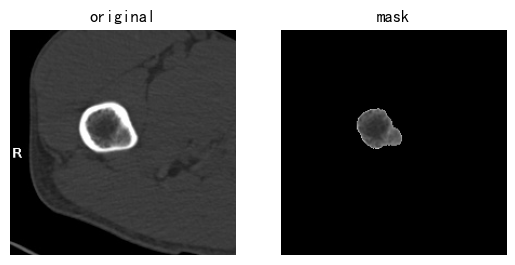

In [ ]:
import cv2
import numpy as np

o = cv2.imread('ct.png')  
plt.subplot(121)
plt.imshow(o)
plt.title("original")
plt.axis("off")

gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
cnt = contours[2]   #coutours[0]、coutours[1]是左侧字母R
#--------使用掩膜获取感兴趣区域的最值-----------------
# 需要注意minMaxLoc处理的对象为灰度图像，本例中处理对象为灰度图像gray
# 如果希望获取彩色图像的，需要提取各个通道，将每个通道独立计算
mask = np.zeros(gray.shape, np.uint8)
mask = cv2.drawContours(mask, [cnt], -1, 255, -1)   
minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(gray, mask = mask)
print("minVal =", minVal)
print("maxVal =", maxVal)
print("minLoc =", minLoc)
print("maxLoc =", maxLoc)
# 计算颜色平均值和灰度平均值
meanVal = cv2.mean(o, mask=mask)
print("meanVal =", meanVal) # 结果是 RGB 和 A 通道(alpha通道)
meanVal_gray = cv2.mean(gray, mask=mask)
print("meanVal_gray =", meanVal_gray)
#--------使用掩膜获取感兴趣区域并显示-----------------
masko = np.zeros(o.shape, np.uint8)
masko = cv2.drawContours(masko, [cnt], -1, (255,255,255), -1)
loc = cv2.bitwise_and(o, masko) 
plt.subplot(122)
plt.imshow(loc)
plt.title("mask")
plt.axis("off")
plt.show()

##### 极点
- 获取某个对象内的极值点，通常的语法格式为
    - `leftmost = tuple(cnt[cnt[:, :, 0].argmin()][0])` 最左端
    - `rightmost = tuple(cnt[cnt[:, :, 0].argmax()][0])` 最右端
    - `topmost = tuple(cnt[cnt[:, :, 1].argmin()][0])` 最上端
    - `bottommost = tuple(cnt[cnt[:, :, 1].argmax()][0])` 最下端

leftmost = (np.int32(202), np.int32(135))
rightmost = (np.int32(423), np.int32(120))
topmost = (np.int32(369), np.int32(69))
bottommost = (np.int32(216), np.int32(179))


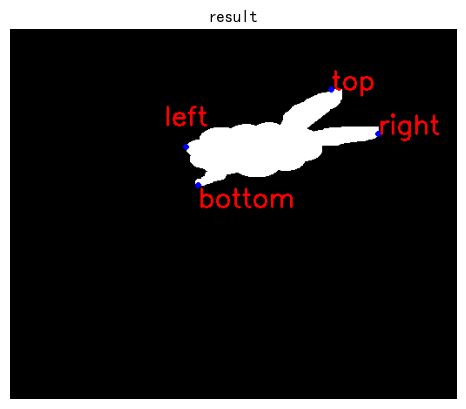

In [54]:
import cv2
import numpy as np

o = cv2.imread('cs.bmp')  
#--------获取并绘制轮廓-----------------
gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
mask = np.zeros(gray.shape, np.uint8)
cnt = contours[0] 
cv2.drawContours(mask, [cnt], 0, 255, -1)
#------- 分别计算左、右、上、下四个点 ----------------- 
leftmost = tuple(cnt[cnt[:,:,0].argmin()][0])
rightmost = tuple(cnt[cnt[:,:,0].argmax()][0])
topmost = tuple(cnt[cnt[:,:,1].argmin()][0])
bottommost = tuple(cnt[cnt[:,:,1].argmax()][0])
#-------- 计算极值 ----------------- 
print("leftmost =", leftmost)
print("rightmost =", rightmost)
print("topmost =", topmost)
print("bottommost =", bottommost)
#--------绘制极点----------------- 
cv2.circle(o, leftmost, 2, (0,0,255), 2)
cv2.circle(o, rightmost, 2, (0,0,255), 2)
cv2.circle(o, topmost, 2, (0,0,255), 2)
cv2.circle(o, bottommost, 2, (0,0,255), 2)
#--------设置绘制说明文字位置----------------- 
leftmostLoc = (leftmost[0]-25, leftmost[1]-25) # 调整文字的位置，方便观察
rightmostLoc = rightmost
topmostLoc = topmost
bottommostLoc = (bottommost[0], bottommost[1]+25)
# --------绘制说明文字----------------- 
font=cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(o, 'left', leftmostLoc, font, 1, (255,0,0), 2)
cv2.putText(o, 'right', rightmostLoc, font, 1, (255,0,0), 2)
cv2.putText(o, 'top', topmostLoc, font, 1, (255,0,0), 2)
cv2.putText(o, 'bottom', bottommostLoc, font, 1, (255,0,0), 2)

plt.imshow(o)
plt.title("result")
plt.axis("off")
plt.show()